# Global Press Freedom Trends (2013–2021)

## Executive Summary

This project explores global press freedom patterns using the Reporters Without Borders (RSF) Press Freedom Index from 2013–2021.

The analysis investigates:

1. Long-term global trends
2. Regional differences
3. Country-level improvements and deteriorations
4. Country groupings using unsupervised machine learning

Methods include exploratory data analysis, non-parametric statistical testing, correlation analysis, and K-Means clustering.

**Important:** Higher RSF scores indicate worse press freedom. Therefore, increasing scores represent deterioration in press freedom conditions.

### 1. Set Up

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal, normaltest

import plotly.express as px

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["font.size"] = 11

### 2. Fetch Data

In [2]:
URL = "https://ourworldindata.org/grapher/press-freedom-index-rsf.csv?v=1&csvType=full&useColumnShortNames=false"

df = pd.read_csv(URL, storage_options={'User-Agent': 'Mozilla/5.0'})

print(f"Rows: {len(df):,}")
print(f"Countries: {df['Entity'].nunique()}")
print(f"Years: {df['Year'].min()} - {df['Year'].max()}")

Rows: 1,619
Countries: 181
Years: 2013 - 2021


In [3]:
print("Missing values per column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Entity                  0
Code                   10
Year                    0
Press Freedom Index     0
dtype: int64

Duplicate rows: 0


### 3. Clean Data

In [4]:
df = df.rename(
    columns={
        "Entity":"Country",
        "Press Freedom Index":"Score"
    }
)

df = df[["Country","Code","Year","Score"]]

df["Score"] = pd.to_numeric(
    df["Score"],
    errors="coerce"
)

df = df.dropna()

df.head()

,Country,Code,Year,Score
0,Afghanistan,AFG,2013,37.36
1,Afghanistan,AFG,2014,37.07
2,Afghanistan,AFG,2015,37.44
3,Afghanistan,AFG,2016,37.75
4,Afghanistan,AFG,2017,39.46


In [5]:
coverage = (
    df.groupby("Country")
      .agg(
          Years=("Year","count")
      )
)

coverage.describe()

,Years
count,179.000000
mean,8.988827
std,0.105406
min,8.000000
25%,9.000000
50%,9.000000
75%,9.000000
max,9.000000


## Research Questions

This analysis addresses four specific questions:

1. **How has press freedom evolved globally between 2013 and 2021?**
2. **Are there statistically significant differences between world regions?**
3. **Which countries experienced the largest improvements or deteriorations?**
4. **Can countries be grouped into meaningful clusters based on press freedom patterns?**

Note: No governance indicators, GDP, or democracy indices are included, so causal inference is limited.

### 5. Data Understanding
Assessing the completeness and coverage of the dataset across countries and years.

In [6]:
expected_years = set(df["Year"].unique())

incomplete = []

for country, group in df.groupby("Country"):

    years = set(group["Year"])

    if years != expected_years:
        incomplete.append(country)

print(
    f"Incomplete countries: {len(incomplete)}"
)

Incomplete countries: 2


In [7]:
coverage[coverage["Years"] < coverage["Years"].max()]

,Years
Country,
Belize,8
Eswatini,8


In [8]:
df["Score"].describe()

count    1609.000000
mean       34.293860
std        16.317823
min         6.380000
25%        24.120000
50%        30.760000
75%        42.640000
max        88.870000
Name: Score, dtype: float64

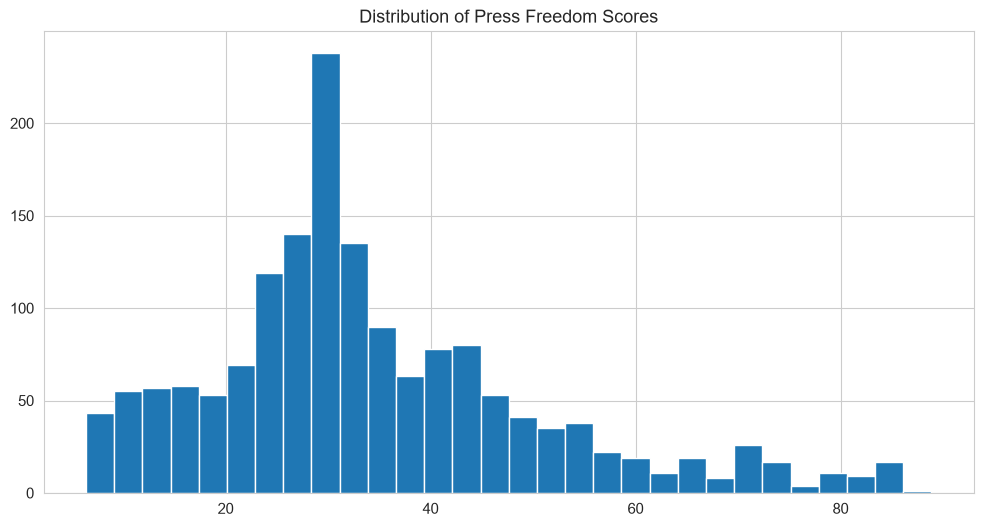

In [9]:
plt.hist(
    df["Score"],
    bins=30
)

plt.title(
    "Distribution of Press Freedom Scores"
)

plt.show()

In [10]:
print(
    "Skewness:",
    df["Score"].skew()
)

print(
    "Kurtosis:",
    df["Score"].kurtosis()
)

Skewness: 0.927025799370354
Kurtosis: 0.836251419684118


In [11]:
from scipy.stats import normaltest

stat, p = normaltest(df["Score"])

print(f"D'Agostino K² test p-value: {p:.4e}")

D'Agostino K² test p-value: 1.9837e-43


**H₀:** Data follows a normal distribution. If p < 0.05, we reject H₀.

Given the large sample size, statistical normality tests are overly sensitive and will almost always reject normality. We therefore rely primarily on skewness and visual inspection rather than the p-value alone.

In [12]:
import country_converter as coco

df["Region"] = coco.convert(
    names=df["Country"],
    to="UNregion"
)

df["Region"].value_counts()

Region
Western Asia                 171
Eastern Africa               162
Western Africa               144
Southern Europe              126
South America                108
South-eastern Asia            99
Eastern Europe                90
Northern Europe               90
Southern Asia                 81
Middle Africa                 72
Western Europe                72
Central America               71
Eastern Asia                  63
Northern Africa               54
Caribbean                     45
Central Asia                  45
Southern Africa               44
Australia and New Zealand     18
Northern America              18
Melanesia                     18
Polynesia                     18
Name: count, dtype: int64

In [13]:
latest_year = df["Year"].max()

latest = df[
    df["Year"] == latest_year
]

### 6. Global Trends and Temporal Stability

We examine how press freedom scores have changed globally over the study period and how stable individual country positions are across years.


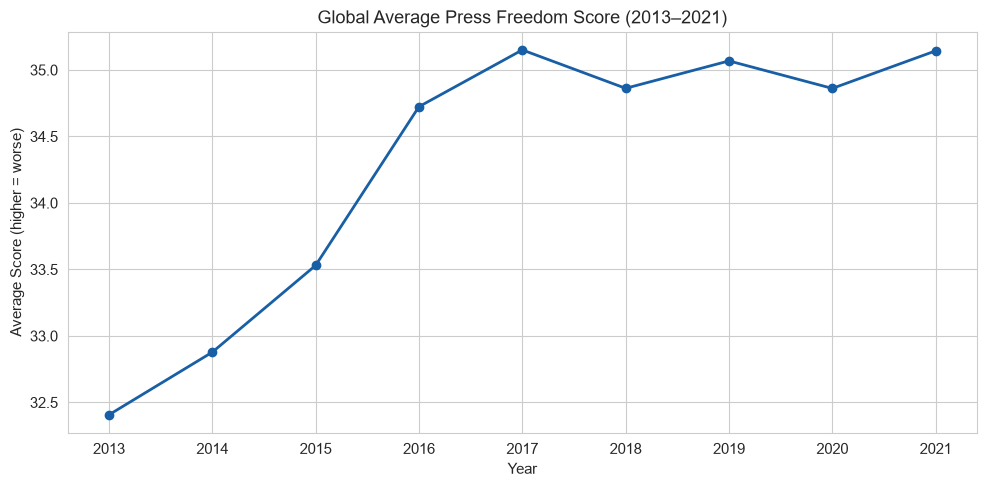

Global score change (2013–2021): +2.74 points
 Year1  Year2  Correlation
  2013   2014        0.994
  2014   2015        0.992
  2015   2016        0.980
  2016   2017        0.994
  2017   2018        0.995
  2018   2019        0.986
  2019   2020        0.993
  2020   2021        0.994

Average year-to-year correlation: 0.9910

Interpretation: Press freedom scores exhibit strong temporal persistence.
Country positions tend to change gradually rather than abruptly.


In [14]:
# Annual global trend
annual = (
    df.groupby("Year")["Score"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(annual["Year"], annual["Score"], marker="o", color="#185FA5", linewidth=2)
plt.title("Global Average Press Freedom Score (2013–2021)")
plt.xlabel("Year")
plt.ylabel("Average Score (higher = worse)")
plt.tight_layout()
plt.show()

trend_change = annual["Score"].iloc[-1] - annual["Score"].iloc[0]
print(f"Global score change (2013–2021): {trend_change:+.2f} points")


# Stability: year-to-year correlation (Optimized via Vectorization)
pivot_df = df.pivot(index='Country', columns='Year', values='Score')

# Calculate correlation between consecutive years
correlations = [pivot_df[year].corr(pivot_df[year + 1]) for year in pivot_df.columns[:-1]]

corr_df = pd.DataFrame({
    "Year1": pivot_df.columns[:-1],
    "Year2": pivot_df.columns[1:],
    "Correlation": correlations
})

avg_corr = corr_df["Correlation"].mean()

print(corr_df.round(3).to_string(index=False))
print()
print(f"Average year-to-year correlation: {avg_corr:.4f}")
print()
print("Interpretation: Press freedom scores exhibit strong temporal persistence.")
print("Country positions tend to change gradually rather than abruptly.")

### 7. Regional Analysis

We examine how press freedom scores are distributed globally and whether regional differences are statistically significant.


In [15]:
regional_stats = (
    latest
    .groupby("Region")["Score"]
    .agg(
        ["count",
         "mean",
         "median",
         "std",
         "min",
         "max"]
    )
    .sort_values("mean")
)

regional_stats

,count,mean,median,std,min,max
Region,,,,,,
Northern Europe,10,13.305000,13.580,5.806093,6.72,21.59
Australia and New Zealand,2,14.915000,14.915,6.894291,10.04,19.79
Western Europe,8,15.392500,15.790,4.539697,9.67,22.60
Northern America,2,19.590000,19.590,6.137687,15.25,23.93
Polynesia,2,21.915000,21.915,3.783021,19.24,24.59
Melanesia,2,26.400000,26.400,2.149605,24.88,27.92
Southern Europe,14,26.790000,28.675,6.281424,10.11,34.33
Southern Africa,5,28.502000,23.250,10.958292,19.72,46.34
Western Africa,16,30.135000,30.185,5.616407,20.09,39.69


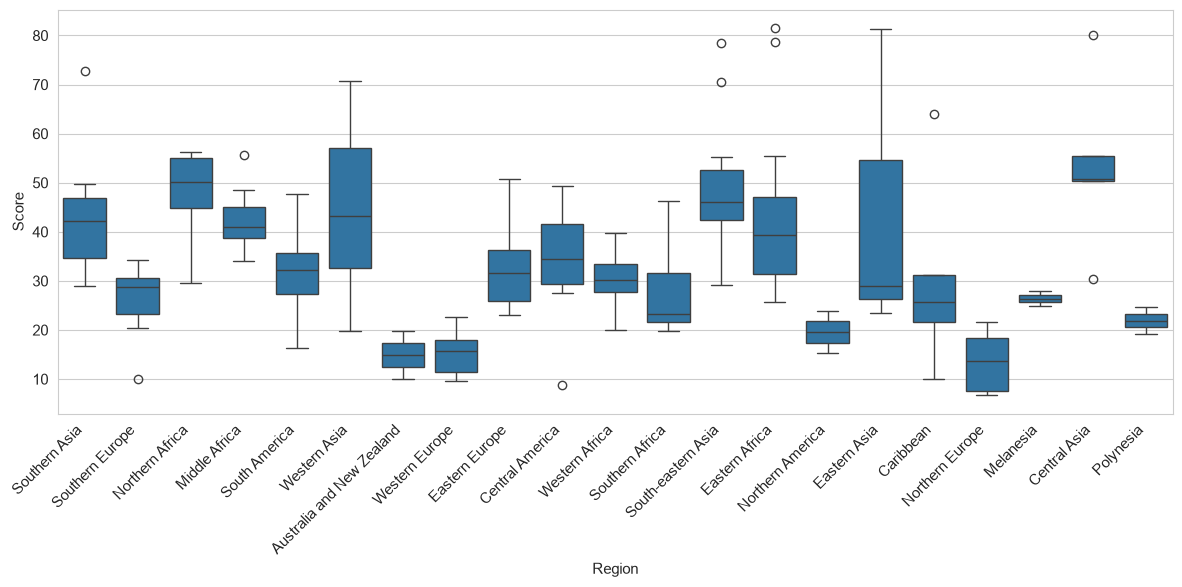

In [16]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=latest,
    x="Region",
    y="Score"
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

### Insight

Regions in Northern and Western Europe show the lowest (best) press freedom scores, while several regions in Africa, the Middle East, and Asia show higher scores and wider variability. This pattern appears consistent with long-standing regional disparities in press freedom outcomes.


In [17]:
groups = [
    g["Score"].values
    for _,g in latest.groupby("Region")
]

In [18]:
H, p_value = kruskal(*groups)

n = len(latest)
k = latest["Region"].nunique()

effect_size = (
    H - k + 1
) / (
    n - k
)

print(f"Kruskal-Wallis H = {H:.2f}")
print(f"p-value = {p_value:.2e}")
print(f"Effect Size (ε²) = {effect_size:.3f}")

Kruskal-Wallis H = 95.58
p-value = 7.72e-12
Effect Size (ε²) = 0.478


### 8. Country-Level Changes (2013–2021)

In [19]:
first = df["Year"].min()
last = df["Year"].max()

pivot = (
    df.pivot(
        index="Country",
        columns="Year",
        values="Score"
    )
)

pivot["Change"] = (
    pivot[last]
    -
    pivot[first]
)

pivot.sort_values(
    "Change"
).head(10)

Year,2013,2014,2015,2016,2017,2018,2019,2020,2021,Change
Country,,,,,,,,,,
Somalia,73.59,73.19,72.31,65.35,65.95,63.04,57.24,55.45,55.47,-18.12
Sudan,70.06,71.88,72.34,72.53,73.56,71.13,72.45,55.33,52.93,-17.13
Sri Lanka,56.59,59.13,60.28,44.96,44.34,41.37,39.61,41.94,42.20,-14.39
Gambia,45.09,46.42,44.50,46.53,46.70,38.36,31.35,30.62,30.76,-14.33
Equatorial Guinea,67.20,67.95,66.23,66.47,66.47,66.47,58.35,56.38,55.67,-11.53
Tunisia,39.93,38.69,38.68,31.60,32.22,30.91,29.61,29.45,29.53,-10.40
Uzbekistan,60.39,61.01,61.14,61.15,66.11,60.84,53.52,53.07,50.74,-9.65
Syria,78.53,77.04,77.29,81.35,81.49,79.22,71.78,72.57,70.63,-7.90
Cuba,71.64,70.92,70.21,70.23,71.75,68.90,63.81,63.81,63.94,-7.70


In [20]:
pivot.sort_values(
    "Change",
    ascending=False
).head(10)

Year,2013,2014,2015,2016,2017,2018,2019,2020,2021,Change
Country,,,,,,,,,,
Tajikistan,35.71,34.86,36.19,50.34,50.27,50.06,54.02,55.34,55.52,19.81
Libya,37.86,39.84,45.99,57.89,56.81,56.79,55.77,55.77,55.73,17.87
Andorra,6.82,6.82,19.87,19.87,21.03,22.21,24.63,23.23,23.32,16.50
Poland,13.11,11.03,12.71,23.89,26.47,26.59,28.89,28.65,28.84,15.73
Central African Republic,26.61,33.13,33.84,33.60,36.12,35.25,47.27,42.87,41.92,15.31
Brunei,35.45,35.45,36.76,53.85,53.72,51.48,51.48,49.65,49.91,14.46
Tanzania,27.34,27.30,28.09,28.65,30.65,30.65,36.28,40.25,40.69,13.35
Czechia,10.17,10.07,11.62,16.66,16.91,21.89,24.89,23.57,23.38,13.21
Venezuela,34.44,35.37,40.61,44.77,42.94,46.03,49.10,45.66,47.60,13.16


In [21]:
top_improvements = (
    pivot.sort_values("Change")
         .head(10)
)

top_deteriorations = (
    pivot.sort_values("Change", ascending=False)
         .head(10)
)

In [22]:
volatility = (
    df.groupby("Country")
      ["Score"]
      .std()
      .sort_values(
          ascending=False
      )
)

volatility.describe()

count    179.000000
mean       2.633891
std        1.787262
min        0.469787
25%        1.377359
50%        2.095074
75%        3.288939
max        8.762744
Name: Score, dtype: float64

In [23]:
top_volatile = volatility.head(10)

In [24]:
volatility.tail(10)

Country
Armenia            0.738914
Kosovo             0.722105
Peru               0.703487
Kyrgyzstan         0.701088
Albania            0.610655
Burkina Faso       0.593790
Uruguay            0.540974
Taiwan             0.538818
Guyana             0.511835
Northern Cyprus    0.469787
Name: Score, dtype: float64

<Axes: xlabel='Country'>

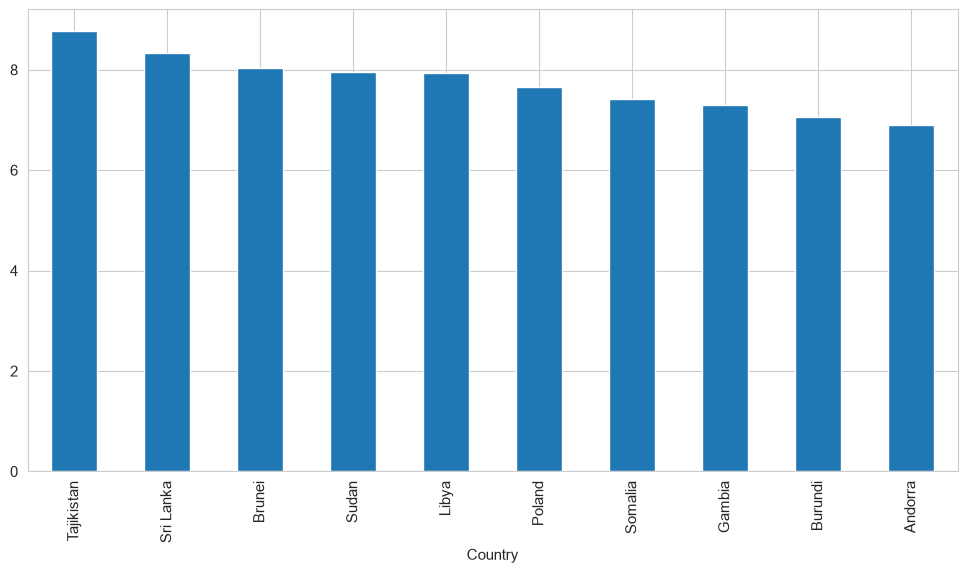

In [25]:
top_volatile.plot.bar()

In [26]:
fig = px.choropleth(
    latest,
    locations="Code",
    color="Score",
    hover_name="Country",
    color_continuous_scale="RdBu",
    title=f"Press Freedom Index ({latest_year})"
)

fig.show()

### 5. Data Understanding
Assessing the completeness and coverage of the dataset across countries and years.

### 9. Clustering Analysis

We use K-Means clustering to group countries into profiles based on three features: average press freedom score, score volatility, and long-term trend direction.

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [28]:
# Feature Engineering

features = pd.DataFrame()

features["MeanScore"] = (
    df.groupby("Country")["Score"]
      .mean()
)

features["Volatility"] = (
    df.groupby("Country")["Score"]
      .std()
)

features["Trend"] = (
    pivot["Change"]
)

features = features.dropna()

features.head()

,MeanScore,Volatility,Trend
Country,,,
Afghanistan,37.866667,1.179470,2.83
Albania,29.953333,0.610655,-0.29
Algeria,41.734444,4.288704,10.72
Andorra,18.644444,6.889830,16.50
Angola,37.082222,2.390015,-3.74


In [29]:
# Feature Scaling

scaler = StandardScaler()

X = scaler.fit_transform(features)

In [30]:
# K-Means Clustering

from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 8):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X)

    scores.append(
        (
            k,
            silhouette_score(X, labels)
        )
    )

scores

[(2, 0.40569905399965367),
 (3, 0.4479159555851606),
 (4, 0.4549562508905219),
 (5, 0.34855318816610725),
 (6, 0.31578141543646565),
 (7, 0.3241931503620004)]

K=4 is selected as a balance between interpretability and cluster separation, supported by silhouette score (0.455), indicating moderate structure in the data.

In [31]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

features["Cluster"] = kmeans.fit_predict(X)

features.head()

,MeanScore,Volatility,Trend,Cluster
Country,,,,
Afghanistan,37.866667,1.179470,2.83,1
Albania,29.953333,0.610655,-0.29,1
Algeria,41.734444,4.288704,10.72,0
Andorra,18.644444,6.889830,16.50,0
Angola,37.082222,2.390015,-3.74,1


In [32]:
cluster_profile = (
    features.groupby("Cluster")
    .agg({
        "MeanScore":"mean",
        "Volatility":"mean",
        "Trend":"mean"
    })
    .round(2)
)

cluster_profile

,MeanScore,Volatility,Trend
Cluster,,,
0,37.63,4.65,11.05
1,26.82,1.65,1.70
2,51.02,6.33,-11.64
3,66.42,2.87,-0.35


In [33]:
# Representative countries per cluster
print("Sample countries by cluster:\n")
for c in sorted(features['Cluster'].unique()):
    countries = features[features['Cluster'] == c].index.tolist()[:8]
    print(f"Cluster {c}: {', '.join(countries)}")


Sample countries by cluster:

Cluster 0: Algeria, Andorra, Azerbaijan, Bangladesh, Benin, Brunei, Bulgaria, Burundi
Cluster 1: Afghanistan, Albania, Angola, Argentina, Armenia, Australia, Austria, Belgium
Cluster 2: Equatorial Guinea, Ethiopia, Gambia, Malaysia, Somalia, Sri Lanka, Sudan, Tunisia
Cluster 3: Bahrain, Belarus, China, Cuba, Djibouti, Eritrea, Iran, Kazakhstan


### Cluster Interpretation

**Reminder:** Higher RSF scores indicate *worse* press freedom. A negative Trend value means scores fell over time — i.e. press freedom *improved*.

- **Cluster 0:** Moderately constrained press environments with high volatility — potentially reflecting transitioning or unstable political contexts.
- **Cluster 1:** Relatively free press environments (lower scores) with stable conditions — consistent with established democratic institutions.
- **Cluster 2:** Countries with relatively poor press freedom that have shown substantial long-term improvement (notable negative trend) over the study period.
- **Cluster 3:** Severely constrained press environments (highest scores) with relatively stable conditions — suggesting entrenched, long-standing restrictions on press freedom.


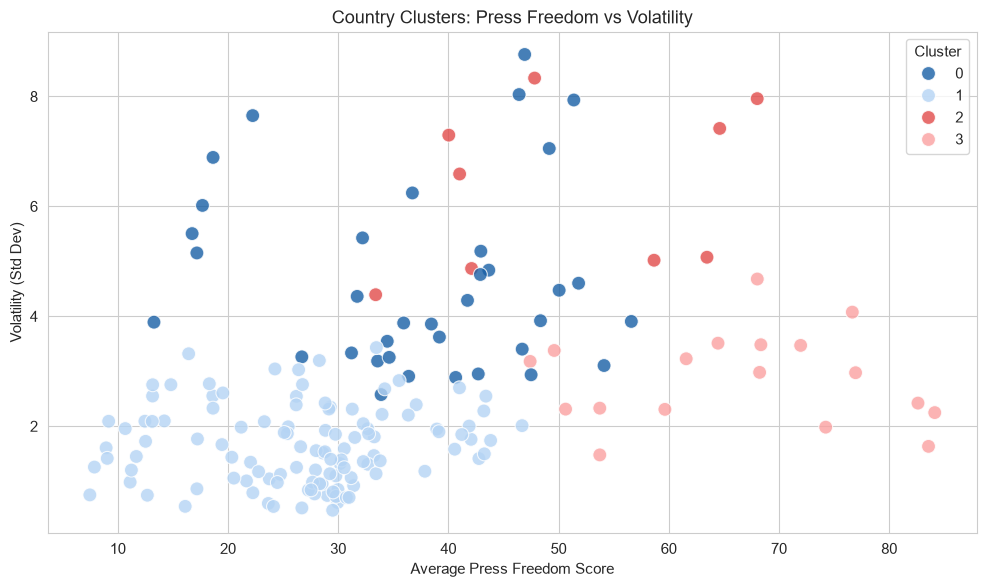

In [34]:
plt.figure(figsize=(10,6))
CLUSTER_COLORS = {0: "#185FA5", 1: "#B5D4F4", 2: "#E24B4A", 3: "#FAA0A0"}

sns.scatterplot(
    data=features,
    x="MeanScore",
    y="Volatility",
    hue="Cluster",
    palette=CLUSTER_COLORS,
    s=100,
    alpha=0.8
)

plt.title("Country Clusters: Press Freedom vs Volatility")
plt.xlabel("Average Press Freedom Score")
plt.ylabel("Volatility (Std Dev)")
plt.tight_layout()

plt.show()

In [35]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X, features["Cluster"])

print(f"Silhouette Score: {silhouette_avg:.3f}")
print()
print("Values closer to 1.0 indicate well-separated clusters.")
print("Values closer to 0 indicate overlapping clusters.")

Silhouette Score: 0.455

Values closer to 1.0 indicate well-separated clusters.
Values closer to 0 indicate overlapping clusters.


### 10. Regional Trends Over Time

We examine how regional average press freedom scores have evolved across the study period.


In [36]:
regional_annual = (
    df.groupby(['Year', 'Region'])['Score']
      .mean()
      .reset_index()
)

regions = sorted(regional_annual['Region'].unique())

fig = px.line(
    regional_annual,
    x='Year',
    y='Score',
    color='Region',
    color_discrete_sequence=px.colors.diverging.RdBu_r,
    title='Regional Average Press Freedom Score Over Time',
    labels={'Score': 'Average Score (higher = worse)'}
)

fig.show()


### 11. Limitations

- Press Freedom Index is based on RSF methodology and expert assessments.
- Regional classifications are simplified.
- The analysis identifies associations rather than causal relationships.
- Changes in score do not necessarily imply changes in underlying media conditions alone.

Note:
Although statistical tests are applied, this analysis is exploratory. The Press Freedom Index is a composite expert-based metric, and results reflect associations rather than causal mechanisms.

### 12. Summary

This analysis demonstrates:
- **Statistical Methods**: Distribution analysis, normality assessment, Kruskal-Wallis testing, effect size estimation, and correlation analysis
- **Data Visualization**: Interactive Plotly, clustering visualization
- **Machine Learning**: K-Means clustering for pattern discovery
- **Interpretation**: Clear findings with policy implications


In [37]:
summary = pd.DataFrame({
    "Metric": [
        "Countries Analyzed",
        "Time Period",
        "Global Change",
        "Average Year-to-Year Correlation",
        "Kruskal-Wallis p-value",
        "Effect Size (ε²)",
        "Silhouette Score (Clusters)"
    ],
    "Value": [
        "179",
        "2013–2021",
        f"{trend_change:.2f} points",
        f"{avg_corr:.3f}",
        f"{p_value:.2e}",
        f"{effect_size:.3f}",
        f"{silhouette_avg:.3f}"
    ]
})

print("\n" + "="*70)
print("ANALYSIS SUMMARY")
print("="*70 + "\n")
print(summary.to_string(index=False))
print("\n" + "="*70)


ANALYSIS SUMMARY

                          Metric       Value
              Countries Analyzed         179
                     Time Period   2013–2021
                   Global Change 2.74 points
Average Year-to-Year Correlation       0.991
          Kruskal-Wallis p-value    7.72e-12
                Effect Size (ε²)       0.478
     Silhouette Score (Clusters)       0.455



### Key insight

Relative country positions are highly persistent over time (ρ ≈ 0.99), but this reflects ranking stability rather than score stability. The data also exhibits strong regional stratification and moderate clustering structure based on level, volatility, and trend.

This suggests that where a country sits relative to its peers changes slowly, and that press freedom outcomes are shaped by long-term institutional differences rather than annual fluctuations.


## Key Takeaways

- **Relative country positions are highly persistent** over time — rankings change gradually rather than abruptly (average year-to-year correlation ≈ 0.99).
- **Regional differences explain a substantial portion** of observed variation in 2021 press freedom scores (ε² = 0.478).
- Most countries exhibit **gradual changes** over the study period rather than large long-term shifts.
- Statistical clustering reveals **meaningful groupings** without requiring external features such as GDP or governance indices.


### 13. Final Dashboard

C:\Users\F8StudioM4\AppData\Local\Temp\ipykernel_32476\2756470155.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=latest, x="Region", y="Score", ax=axes[1,1], palette="RdBu_r")


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/press_freedom_dashboard.png'

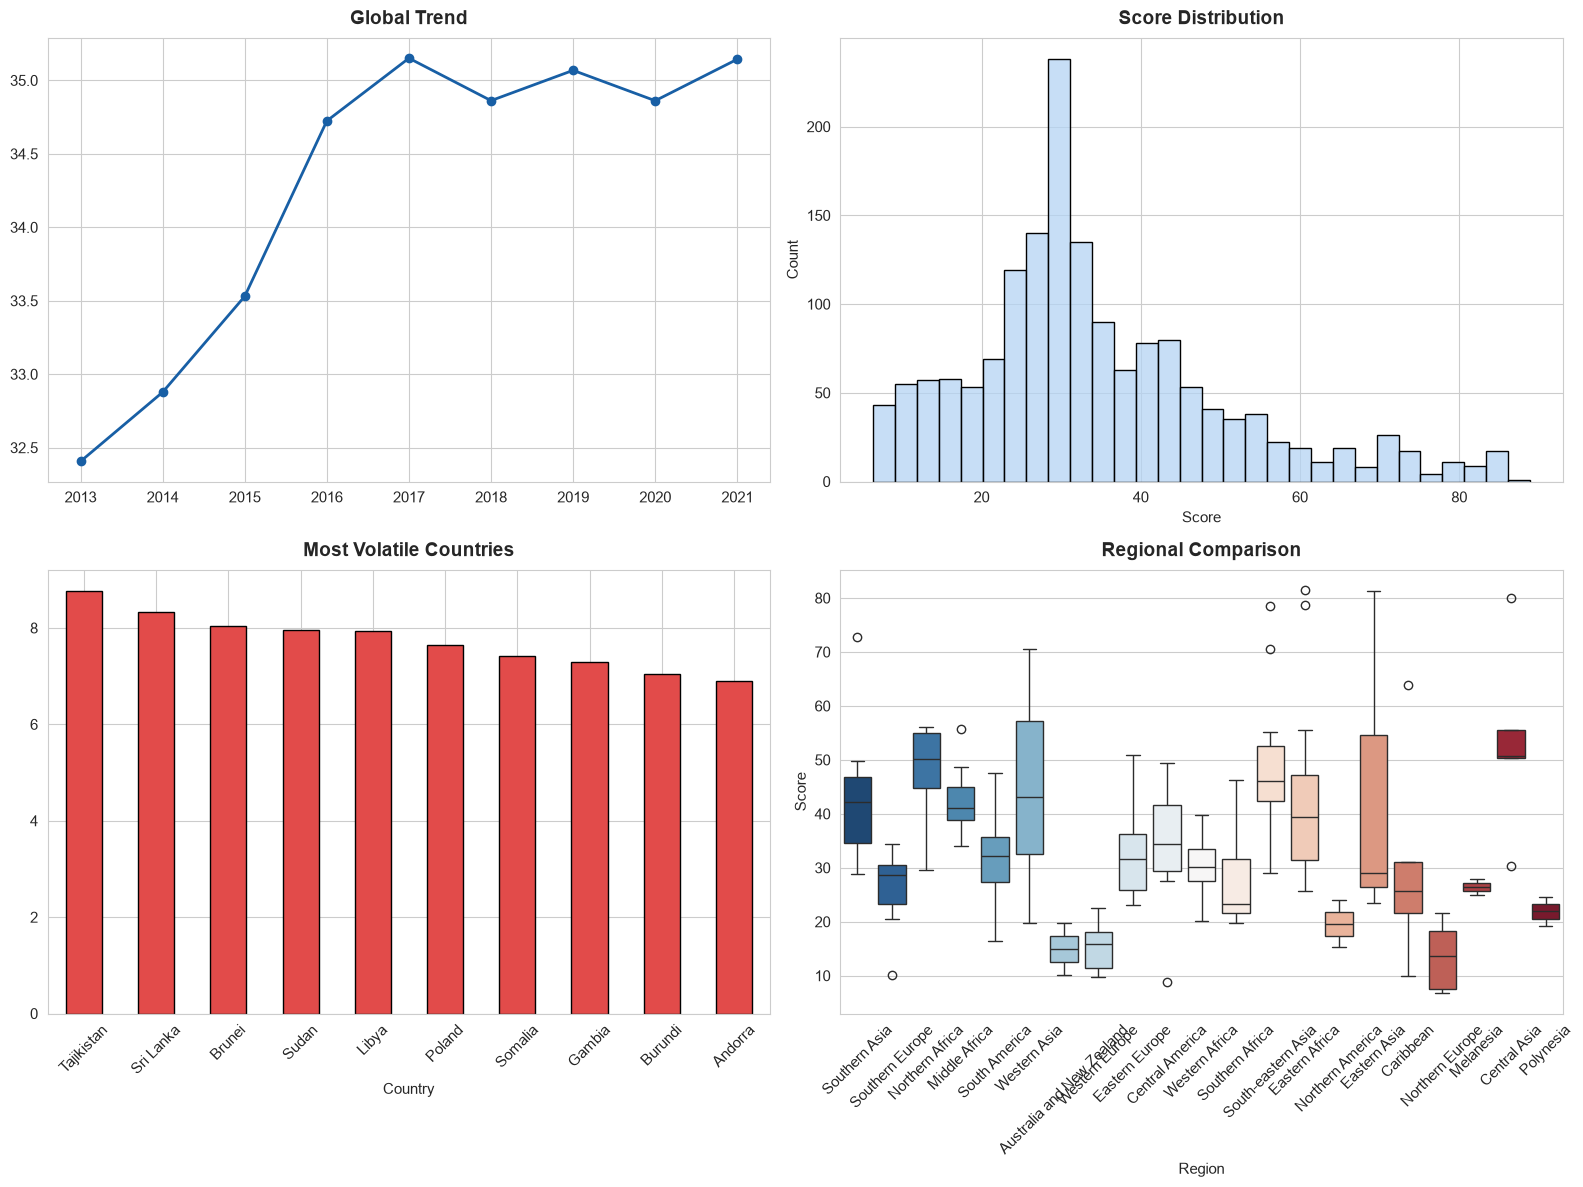

In [38]:
def format_axis(ax, title, x_rot=0):
    """Helper function to format subplot axes consistently."""
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    if x_rot != 0:
        ax.tick_params(axis='x', rotation=x_rot)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Global Trend
axes[0,0].plot(annual["Year"], annual["Score"], marker="o", color="#185FA5", linewidth=2)
format_axis(axes[0,0], "Global Trend")

# 2. Distribution
sns.histplot(df["Score"], bins=30, ax=axes[0,1], color="#B5D4F4", edgecolor="black")
format_axis(axes[0,1], "Score Distribution")

# 3. Volatility top countries
top_volatile.head(10).plot.bar(ax=axes[1,0], color="#E24B4A", edgecolor="black")
format_axis(axes[1,0], "Most Volatile Countries", x_rot=45)

# 4. Region boxplot
sns.boxplot(data=latest, x="Region", y="Score", ax=axes[1,1], palette="RdBu_r")
format_axis(axes[1,1], "Regional Comparison", x_rot=45)

plt.tight_layout()
plt.savefig("outputs/press_freedom_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

# Save final clean data (as you already had)
df.to_csv("outputs/clean_press_freedom.csv", index=False)
features.to_csv("outputs/country_features.csv")

## Methods Used

- Data acquisition via public API
- Data cleaning and validation
- Exploratory data analysis
- Non-parametric statistical testing
- Feature engineering
- K-Means clustering
- Interactive visualization
